# Tsukamoto Fuzzy Inference — Self-Study Notebook

**Module:** Artificial Intelligence  
**Topic:** Fuzzy Logic — Tsukamoto Inference Model

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain how Tsukamoto inference differs from Mamdani and Sugeno
2. Understand the **monotonic membership function** constraint and why it exists
3. Implement Tsukamoto inference **from scratch** in Python
4. Verify your results using **pyfuzzylite**
5. Compare the outputs of all three inference models on the same problem

---

## Background

The **Tsukamoto model** (1979) is the third major fuzzy inference method alongside Mamdani and Sugeno. Like Sugeno, it avoids the computationally expensive defuzzification step of Mamdani by producing a **crisp output from each rule**, then combining them with a **weighted average**.

The key mechanism: each rule's output membership function must be **monotonic** (either always increasing or always decreasing). Given a rule's firing strength $w_i$, Tsukamoto finds the crisp value $z_i$ where the output MF equals $w_i$ — essentially **inverting** the membership function. The final output is:

$$Z = \frac{\sum_{i=1}^{n} w_i \cdot z_i}{\sum_{i=1}^{n} w_i}$$

### Comparison of the Three Models

| Aspect | Mamdani | Sugeno | Tsukamoto |
|--------|---------|--------|-----------|
| Output MFs | Distributed fuzzy sets | Constants or functions | **Monotonic** fuzzy sets |
| Rule output | Fuzzy set (clipped/scaled) | Crisp value (direct) | Crisp value (by MF inversion) |
| Aggregation | Union of fuzzy sets | Weighted average | Weighted average |
| Defuzzification | COG, MOM, etc. | Not needed | Not needed |
| Computational cost | High | Low | Low |
| Transparency | High (can plot aggregated set) | Medium | Low |

### The Monotonic Constraint

Why must Tsukamoto output MFs be monotonic? Because the inference step **inverts** the MF: given firing strength $w_i$, it solves $\mu(z_i) = w_i$ for $z_i$. If the MF is non-monotonic (e.g. a triangle), there could be **two values** of $z$ that satisfy this equation, making the result ambiguous.

In practice, this means Tsukamoto output terms use **ramps** (linear) or **sigmoids** (smooth) rather than the triangles and trapezoids common in Mamdani. This is both its strength (computationally efficient) and its limitation (less intuitive output representation).

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12

print("Setup complete.")

Setup complete.


---

## Part 1: The Restaurant Tipper Problem

We use the classic **MATLAB tipper** example from the lecture slides:

- **Input 1:** `service` (1–10)
- **Input 2:** `food` (1–10)
- **Output:** `tip` (5–25%)

**Rules:**
1. If service is **poor** OR food is **rancid**, then tip is **cheap**
2. If service is **good**, then tip is **average**
3. If service is **excellent** OR food is **delicious**, then tip is **generous**

### 1.1 — Input Membership Functions

The input MFs are the **same** as in Mamdani and Sugeno — Tsukamoto only changes the *output* representation. We use the standard MATLAB tipper MFs:

- **Service:** poor = Gaussian(1.5, 0), good = Gaussian(1.5, 5), excellent = Gaussian(1.5, 10)
- **Food:** rancid = Trapezoid(0, 0, 1, 3), delicious = Trapezoid(7, 9, 10, 10)

In [2]:
# --- Membership function primitives ---

def gaussmf(x, sigma, centre):
    """Gaussian membership function."""
    return np.exp(-0.5 * ((x - centre) / sigma) ** 2)


def trapmf(x, a, b, c, d):
    """Trapezoidal membership function."""
    return np.maximum(0, np.minimum(1, np.minimum((x - a) / (b - a + 1e-12),
                                                   (d - x) / (d - c + 1e-12))))


def ramp_ascending(x, a, b):
    """Ascending ramp: 0 at x<=a, 1 at x>=b, linear between."""
    return np.clip((x - a) / (b - a), 0, 1)


def ramp_descending(x, a, b):
    """Descending ramp: 1 at x<=a, 0 at x>=b, linear between."""
    return np.clip((b - x) / (b - a), 0, 1)


# --- Input MFs (same as Mamdani) ---

def service_poor(x):      return gaussmf(x, 1.5, 0)
def service_good(x):      return gaussmf(x, 1.5, 5)
def service_excellent(x): return gaussmf(x, 1.5, 10)

def food_rancid(x):       return trapmf(x, 0, 0, 1, 3)
def food_delicious(x):    return trapmf(x, 7, 9, 10, 10)

print("Membership functions defined.")

Membership functions defined.


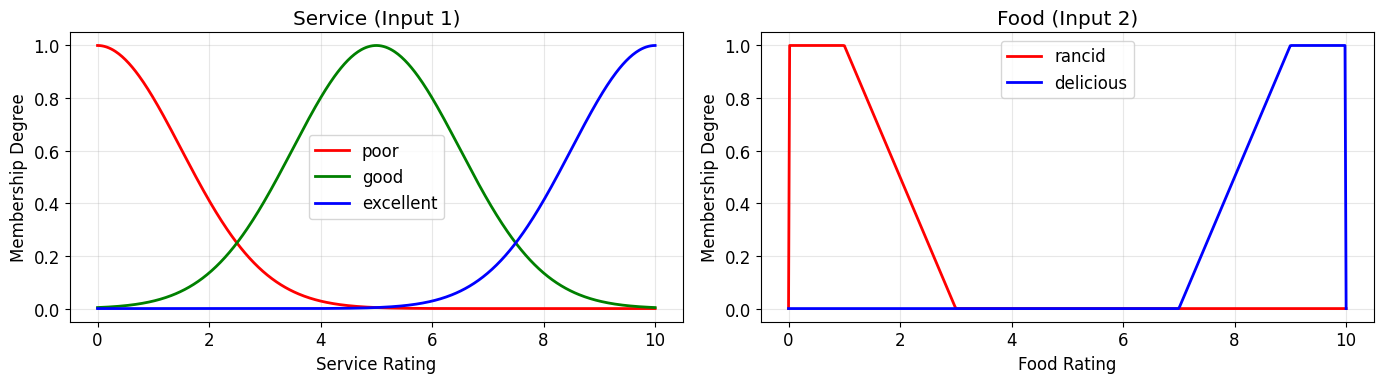

In [3]:
# Plot input MFs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x_service = np.linspace(0, 10, 500)
axes[0].plot(x_service, service_poor(x_service), 'r-', lw=2, label='poor')
axes[0].plot(x_service, service_good(x_service), 'g-', lw=2, label='good')
axes[0].plot(x_service, service_excellent(x_service), 'b-', lw=2, label='excellent')
axes[0].set_title('Service (Input 1)')
axes[0].set_xlabel('Service Rating')
axes[0].set_ylabel('Membership Degree')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

x_food = np.linspace(0, 10, 500)
axes[1].plot(x_food, food_rancid(x_food), 'r-', lw=2, label='rancid')
axes[1].plot(x_food, food_delicious(x_food), 'b-', lw=2, label='delicious')
axes[1].set_title('Food (Input 2)')
axes[1].set_xlabel('Food Rating')
axes[1].set_ylabel('Membership Degree')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 — Output Membership Functions (Tsukamoto vs Mamdani)

This is where Tsukamoto diverges from Mamdani. In Mamdani, the tip output uses triangles:
- cheap = Triangle(0, 5, 10)
- average = Triangle(10, 15, 20)
- generous = Triangle(20, 25, 30)

But Tsukamoto requires **monotonic** MFs. The standard approach is to use **ramps**:

| Term | Type | Range | Meaning |
|------|------|-------|---------|
| cheap | Descending ramp | 5% → 12% | High membership at low tip values |
| average | Ascending ramp | 10% → 18% | High membership at mid tip values |
| generous | Ascending ramp | 18% → 25% | High membership at high tip values |

Each ramp is invertible: given a firing strength $w$, we can solve for the unique crisp tip value $z$ where $\mu(z) = w$.

In [4]:
# --- Tsukamoto output MFs (monotonic ramps) ---

def tip_cheap(x):     return ramp_descending(x, 5, 12)     # mu=1 at 5%, mu=0 at 12%
def tip_average(x):   return ramp_ascending(x, 10, 18)     # mu=0 at 10%, mu=1 at 18%
def tip_generous(x):  return ramp_ascending(x, 18, 25)     # mu=0 at 18%, mu=1 at 25%


# --- Inverse functions (solve mu(z) = w for z) ---

def inv_cheap(w):
    """Invert descending ramp: mu = (12 - z) / 7, so z = 12 - 7*w"""
    return 12 - 7 * np.clip(w, 0, 1)

def inv_average(w):
    """Invert ascending ramp: mu = (z - 10) / 8, so z = 10 + 8*w"""
    return 10 + 8 * np.clip(w, 0, 1)

def inv_generous(w):
    """Invert ascending ramp: mu = (z - 18) / 7, so z = 18 + 7*w"""
    return 18 + 7 * np.clip(w, 0, 1)


# Verify: inv(mu(x)) should return x
print(f"Verify cheap:    tip_cheap(8.5) = {tip_cheap(8.5):.3f}, inv_cheap({tip_cheap(8.5):.3f}) = {inv_cheap(tip_cheap(8.5)):.1f}")
print(f"Verify average:  tip_average(14) = {tip_average(14):.3f}, inv_average({tip_average(14):.3f}) = {inv_average(tip_average(14)):.1f}")
print(f"Verify generous: tip_generous(21.5) = {tip_generous(21.5):.3f}, inv_generous({tip_generous(21.5):.3f}) = {inv_generous(tip_generous(21.5)):.1f}")

Verify cheap:    tip_cheap(8.5) = 0.500, inv_cheap(0.500) = 8.5
Verify average:  tip_average(14) = 0.500, inv_average(0.500) = 14.0
Verify generous: tip_generous(21.5) = 0.500, inv_generous(0.500) = 21.5


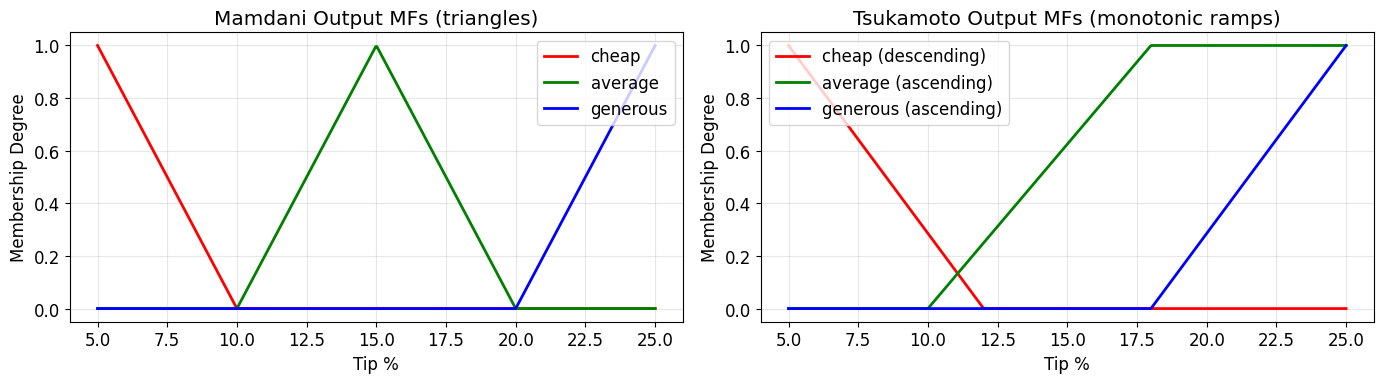

In [5]:
# Plot output MFs: Mamdani (triangles) vs Tsukamoto (ramps)
x_tip = np.linspace(5, 25, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mamdani triangles (for comparison)
from numpy import clip as cl
mamdani_cheap = np.maximum(0, np.minimum((x_tip - 0)/(5 - 0 + 1e-12), (10 - x_tip)/(10 - 5 + 1e-12)))
mamdani_avg   = np.maximum(0, np.minimum((x_tip - 10)/(15 - 10 + 1e-12), (20 - x_tip)/(20 - 15 + 1e-12)))
mamdani_gen   = np.maximum(0, np.minimum((x_tip - 20)/(25 - 20 + 1e-12), (30 - x_tip)/(30 - 25 + 1e-12)))

axes[0].plot(x_tip, mamdani_cheap, 'r-', lw=2, label='cheap')
axes[0].plot(x_tip, mamdani_avg, 'g-', lw=2, label='average')
axes[0].plot(x_tip, mamdani_gen, 'b-', lw=2, label='generous')
axes[0].set_title('Mamdani Output MFs (triangles)')
axes[0].set_xlabel('Tip %')
axes[0].set_ylabel('Membership Degree')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Tsukamoto ramps
axes[1].plot(x_tip, tip_cheap(x_tip), 'r-', lw=2, label='cheap (descending)')
axes[1].plot(x_tip, tip_average(x_tip), 'g-', lw=2, label='average (ascending)')
axes[1].plot(x_tip, tip_generous(x_tip), 'b-', lw=2, label='generous (ascending)')
axes[1].set_title('Tsukamoto Output MFs (monotonic ramps)')
axes[1].set_xlabel('Tip %')
axes[1].set_ylabel('Membership Degree')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Part 2: Tsukamoto Inference From Scratch

### 2.1 — Step-by-Step Worked Example

We will compute the Tsukamoto output for **service = 3, food = 8** (the same inputs used in the lecture slides, which give a Mamdani tip of approximately 16.7%).

The four steps of Tsukamoto inference are:

1. **Fuzzify** the inputs (identical to Mamdani)
2. **Evaluate rules** to get firing strengths $w_i$ (identical to Mamdani)
3. **Invert** each output MF to get crisp values $z_i$ (unique to Tsukamoto)
4. **Weighted average** to get final output

In [6]:
# Crisp inputs
service = 3
food = 8

print("=" * 60)
print(f"TSUKAMOTO INFERENCE: service = {service}, food = {food}")
print("=" * 60)

# ── Step 1: Fuzzification ──
mu_poor      = service_poor(service)
mu_good      = service_good(service)
mu_excellent = service_excellent(service)
mu_rancid    = food_rancid(food)
mu_delicious = food_delicious(food)

print(f"\nStep 1 — Fuzzification:")
print(f"  service_poor({service})      = {mu_poor:.4f}")
print(f"  service_good({service})      = {mu_good:.4f}")
print(f"  service_excellent({service}) = {mu_excellent:.4f}")
print(f"  food_rancid({food})          = {mu_rancid:.4f}")
print(f"  food_delicious({food})       = {mu_delicious:.4f}")

# ── Step 2: Rule Evaluation ──
# Rule 1: IF service IS poor OR food IS rancid THEN tip IS cheap
w1 = max(mu_poor, mu_rancid)        # OR = max

# Rule 2: IF service IS good THEN tip IS average
w2 = mu_good                         # single antecedent

# Rule 3: IF service IS excellent OR food IS delicious THEN tip IS generous
w3 = max(mu_excellent, mu_delicious) # OR = max

print(f"\nStep 2 — Rule Evaluation (firing strengths):")
print(f"  w1 (cheap)    = max({mu_poor:.4f}, {mu_rancid:.4f}) = {w1:.4f}")
print(f"  w2 (average)  = {w2:.4f}")
print(f"  w3 (generous) = max({mu_excellent:.4f}, {mu_delicious:.4f}) = {w3:.4f}")

# ── Step 3: Invert output MFs (Tsukamoto-specific) ──
z1 = inv_cheap(w1)
z2 = inv_average(w2)
z3 = inv_generous(w3)

print(f"\nStep 3 — MF Inversion (crisp rule outputs):")
print(f"  z1 = inv_cheap({w1:.4f})    = {z1:.4f}%")
print(f"  z2 = inv_average({w2:.4f})  = {z2:.4f}%")
print(f"  z3 = inv_generous({w3:.4f}) = {z3:.4f}%")

# ── Step 4: Weighted Average ──
numerator = w1 * z1 + w2 * z2 + w3 * z3
denominator = w1 + w2 + w3
tip = numerator / denominator

print(f"\nStep 4 — Weighted Average:")
print(f"  ({w1:.4f} × {z1:.4f} + {w2:.4f} × {z2:.4f} + {w3:.4f} × {z3:.4f})")
print(f"  ÷ ({w1:.4f} + {w2:.4f} + {w3:.4f})")
print(f"  = {numerator:.4f} / {denominator:.4f}")
print(f"\n  ══> Tip = {tip:.2f}%")

TSUKAMOTO INFERENCE: service = 3, food = 8

Step 1 — Fuzzification:
  service_poor(3)      = 0.1353
  service_good(3)      = 0.4111
  service_excellent(3) = 0.0000
  food_rancid(8)          = 0.0000
  food_delicious(8)       = 0.5000

Step 2 — Rule Evaluation (firing strengths):
  w1 (cheap)    = max(0.1353, 0.0000) = 0.1353
  w2 (average)  = 0.4111
  w3 (generous) = max(0.0000, 0.5000) = 0.5000

Step 3 — MF Inversion (crisp rule outputs):
  z1 = inv_cheap(0.1353)    = 11.0527%
  z2 = inv_average(0.4111)  = 13.2889%
  z3 = inv_generous(0.5000) = 21.5000%

Step 4 — Weighted Average:
  (0.1353 × 11.0527 + 0.4111 × 13.2889 + 0.5000 × 21.5000)
  ÷ (0.1353 + 0.4111 + 0.5000)
  = 17.7090 / 1.0464

  ══> Tip = 16.92%


### 2.2 — Visualise the Inversion Step

The following plot shows the key Tsukamoto mechanism: for each rule, the firing strength $w_i$ is projected onto the output MF to find the crisp value $z_i$.

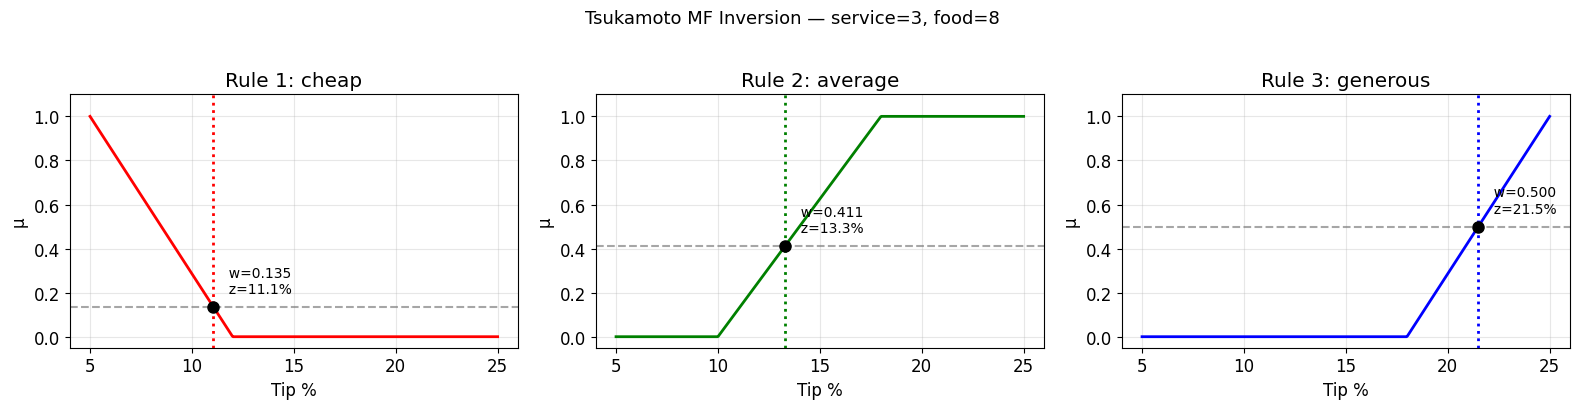

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x_tip = np.linspace(5, 25, 500)

for ax, (label, mf, w, z, colour) in zip(axes, [
    ('Rule 1: cheap', tip_cheap, w1, z1, 'red'),
    ('Rule 2: average', tip_average, w2, z2, 'green'),
    ('Rule 3: generous', tip_generous, w3, z3, 'blue'),
]):
    ax.plot(x_tip, mf(x_tip), colour, lw=2)
    # Horizontal line at firing strength
    ax.axhline(y=w, color='gray', linestyle='--', alpha=0.7)
    # Vertical line at crisp output
    ax.axvline(x=z, color=colour, linestyle=':', lw=2)
    # Mark intersection
    ax.plot(z, w, 'ko', markersize=8, zorder=5)
    ax.annotate(f'  w={w:.3f}\n  z={z:.1f}%', xy=(z, w), fontsize=10,
                xytext=(5, 10), textcoords='offset points')
    ax.set_title(label)
    ax.set_xlabel('Tip %')
    ax.set_ylabel('μ')
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Tsukamoto MF Inversion — service={service}, food={food}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 — Generalised Tsukamoto Function

Now we wrap the inference into a reusable function.

In [8]:
def tsukamoto_tipper(service_val, food_val):
    """Compute tip using Tsukamoto inference for the restaurant tipper."""
    # Fuzzify
    mu_p = service_poor(service_val)
    mu_g = service_good(service_val)
    mu_e = service_excellent(service_val)
    mu_r = food_rancid(food_val)
    mu_d = food_delicious(food_val)

    # Rule firing strengths
    w1 = max(mu_p, mu_r)         # poor OR rancid -> cheap
    w2 = mu_g                    # good -> average
    w3 = max(mu_e, mu_d)         # excellent OR delicious -> generous

    # Invert monotonic output MFs
    z1 = inv_cheap(w1)
    z2 = inv_average(w2)
    z3 = inv_generous(w3)

    # Weighted average
    denom = w1 + w2 + w3
    if denom == 0:
        return 15.0  # default: middle of range
    return (w1 * z1 + w2 * z2 + w3 * z3) / denom


# Test with the worked example
print(f"Tsukamoto tip for service=3, food=8: {tsukamoto_tipper(3, 8):.2f}%")

# Test a few more cases
test_cases = [(1, 1), (5, 5), (9, 9), (1, 9), (9, 1), (3, 8)]
print(f"\n{'Service':>8} {'Food':>6} {'Tip':>8}")
print("-" * 25)
for s, f in test_cases:
    t = tsukamoto_tipper(s, f)
    print(f"{s:>8} {f:>6} {t:>7.2f}%")

Tsukamoto tip for service=3, food=8: 16.92%

 Service   Food      Tip
-------------------------
       1      1    5.15%
       5      5   17.98%
       9      9   24.59%
       1      9   16.63%
       9      1   13.23%
       3      8   16.92%


### 2.4 — Control Surface

Generate the 3D control surface to see the full input–output mapping.

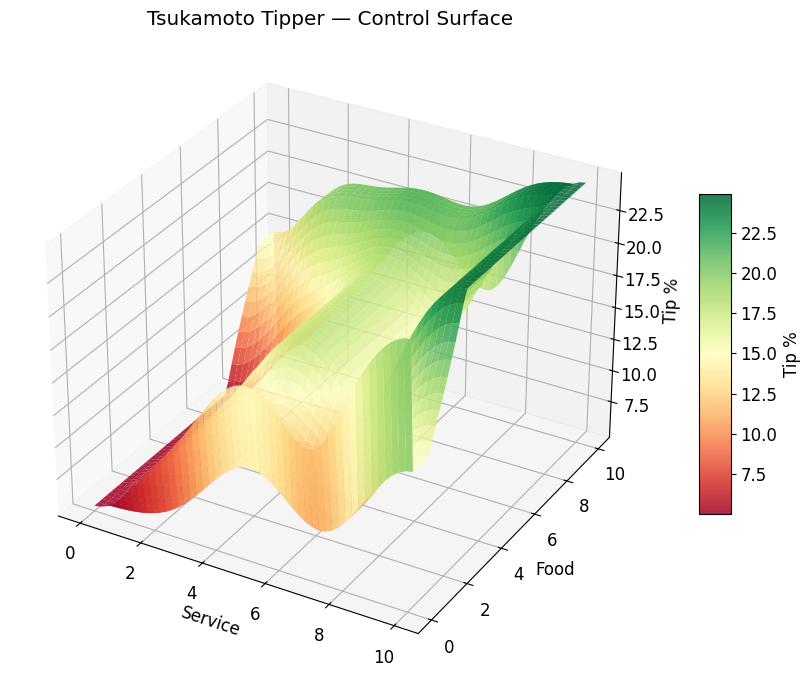

Tip range: 5.02% – 24.94%


In [9]:
s_range = np.linspace(0, 10, 50)
f_range = np.linspace(0, 10, 50)
S, F = np.meshgrid(s_range, f_range)
T = np.zeros_like(S)

for i in range(len(f_range)):
    for j in range(len(s_range)):
        T[i, j] = tsukamoto_tipper(S[i, j], F[i, j])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(S, F, T, cmap='RdYlGn', edgecolor='none', alpha=0.85)
ax.set_xlabel('Service')
ax.set_ylabel('Food')
ax.set_zlabel('Tip %')
ax.set_title('Tsukamoto Tipper — Control Surface')
fig.colorbar(surf, shrink=0.5, aspect=10, label='Tip %')
plt.tight_layout()
plt.show()

print(f"Tip range: {T.min():.2f}% – {T.max():.2f}%")

---

## Part 3: Verification with pyfuzzylite

Now we build the same system in pyfuzzylite to verify our from-scratch implementation. pyfuzzylite supports Tsukamoto via `fl.WeightedAverage("Tsukamoto")` with monotonic output terms (`fl.Ramp`).

In [10]:
import fuzzylite as fl


def get_output(engine, name):
    """Extract a scalar float from a fuzzy engine output variable."""
    val = engine.output_variable(name).value
    return float(val.item()) if hasattr(val, 'item') else float(val)


tsukamoto_engine = fl.Engine(
    name="TipperTsukamoto",
    input_variables=[
        fl.InputVariable(
            name="service", minimum=0, maximum=10,
            terms=[
                fl.Gaussian("poor", 0, 1.5),
                fl.Gaussian("good", 5, 1.5),
                fl.Gaussian("excellent", 10, 1.5),
            ],
        ),
        fl.InputVariable(
            name="food", minimum=0, maximum=10,
            terms=[
                fl.Trapezoid("rancid", 0, 0, 1, 3),
                fl.Trapezoid("delicious", 7, 9, 10, 10),
            ],
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="tip", minimum=5, maximum=25,
            aggregation=None,
            defuzzifier=fl.WeightedAverage("Tsukamoto"),
            terms=[
                fl.Ramp("cheap", 12, 5),       # descending: high at 5, low at 12
                fl.Ramp("average", 10, 18),     # ascending: low at 10, high at 18
                fl.Ramp("generous", 18, 25),    # ascending: low at 18, high at 25
            ],
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(),
            disjunction=fl.Maximum(),
            implication=fl.AlgebraicProduct(),
            activation=fl.General(),
            rules=[
                fl.Rule.create("if service is poor or food is rancid then tip is cheap"),
                fl.Rule.create("if service is good then tip is average"),
                fl.Rule.create("if service is excellent or food is delicious then tip is generous"),
            ],
        ),
    ],
)

print(f"Engine: {tsukamoto_engine.name}")
print(f"Rules: {len(tsukamoto_engine.rule_blocks[0].rules)}")

Engine: TipperTsukamoto
Rules: 3


In [11]:
# Compare from-scratch vs pyfuzzylite
print(f"{'Service':>8} {'Food':>6} {'Scratch':>10} {'PyFuzzyLite':>12} {'Diff':>8}")
print("-" * 50)

for s, f in [(1, 1), (3, 8), (5, 5), (7, 3), (9, 9), (1, 9), (9, 1)]:
    # From scratch
    tip_scratch = tsukamoto_tipper(s, f)

    # pyfuzzylite
    tsukamoto_engine.input_variable("service").value = float(s)
    tsukamoto_engine.input_variable("food").value = float(f)
    tsukamoto_engine.process()
    tip_pfl = get_output(tsukamoto_engine, "tip")

    diff = abs(tip_scratch - tip_pfl)
    print(f"{s:>8} {f:>6} {tip_scratch:>9.2f}% {tip_pfl:>11.2f}% {diff:>7.3f}")

 Service   Food    Scratch  PyFuzzyLite     Diff
--------------------------------------------------
       1      1      5.15%        5.15%   0.000
       3      8     16.92%       16.92%   0.000
       5      5     17.98%       17.98%   0.000
       7      3     14.69%       14.69%   0.000
       9      9     24.59%       24.59%   0.000
       1      9     16.63%       16.63%   0.000
       9      1     13.23%       13.23%   0.000


> **Note:** Small differences between the from-scratch and pyfuzzylite results are expected due to differences in how each implementation handles edge cases (e.g. clipping, Gaussian tails near 0). If the values are within ~0.5%, both implementations are working correctly.

---

## Part 4: Comparing Mamdani, Sugeno, and Tsukamoto

Let's build all three models for the tipper problem and compare their outputs.

In [12]:
# --- Mamdani Tipper ---
mamdani_tipper = fl.Engine(
    name="TipperMamdani",
    input_variables=[
        fl.InputVariable(name="service", minimum=0, maximum=10, terms=[
            fl.Gaussian("poor", 0, 1.5), fl.Gaussian("good", 5, 1.5), fl.Gaussian("excellent", 10, 1.5),
        ]),
        fl.InputVariable(name="food", minimum=0, maximum=10, terms=[
            fl.Trapezoid("rancid", 0, 0, 1, 3), fl.Trapezoid("delicious", 7, 9, 10, 10),
        ]),
    ],
    output_variables=[
        fl.OutputVariable(name="tip", minimum=5, maximum=25,
            aggregation=fl.Maximum(), defuzzifier=fl.Centroid(200),
            terms=[
                fl.Triangle("cheap", 0, 5, 10),
                fl.Triangle("average", 10, 15, 20),
                fl.Triangle("generous", 20, 25, 30),
            ]),
    ],
    rule_blocks=[
        fl.RuleBlock(name="rules", conjunction=fl.Minimum(), disjunction=fl.Maximum(),
            implication=fl.Minimum(), activation=fl.General(), rules=[
                fl.Rule.create("if service is poor or food is rancid then tip is cheap"),
                fl.Rule.create("if service is good then tip is average"),
                fl.Rule.create("if service is excellent or food is delicious then tip is generous"),
            ]),
    ],
)

# --- Sugeno Tipper ---
sugeno_tipper = fl.Engine(
    name="TipperSugeno",
    input_variables=[
        fl.InputVariable(name="service", minimum=0, maximum=10, terms=[
            fl.Gaussian("poor", 0, 1.5), fl.Gaussian("good", 5, 1.5), fl.Gaussian("excellent", 10, 1.5),
        ]),
        fl.InputVariable(name="food", minimum=0, maximum=10, terms=[
            fl.Trapezoid("rancid", 0, 0, 1, 3), fl.Trapezoid("delicious", 7, 9, 10, 10),
        ]),
    ],
    output_variables=[
        fl.OutputVariable(name="tip", minimum=5, maximum=25,
            aggregation=fl.Maximum(), defuzzifier=fl.WeightedAverage("TakagiSugeno"),
            terms=[
                fl.Constant("cheap", 5),
                fl.Constant("average", 15),
                fl.Constant("generous", 25),
            ]),
    ],
    rule_blocks=[
        fl.RuleBlock(name="rules", conjunction=fl.Minimum(), disjunction=fl.Maximum(),
            implication=fl.AlgebraicProduct(), activation=fl.General(), rules=[
                fl.Rule.create("if service is poor or food is rancid then tip is cheap"),
                fl.Rule.create("if service is good then tip is average"),
                fl.Rule.create("if service is excellent or food is delicious then tip is generous"),
            ]),
    ],
)

print("All three engines created.")

All three engines created.


In [13]:
# Compare outputs
print(f"{'Service':>8} {'Food':>6} {'Mamdani':>10} {'Sugeno':>10} {'Tsukamoto':>12}")
print("-" * 52)

for s, f in [(1, 1), (3, 8), (5, 5), (7, 3), (9, 9), (1, 9), (9, 1), (5, 1), (5, 9)]:
    results = []
    for engine in [mamdani_tipper, sugeno_tipper, tsukamoto_engine]:
        engine.input_variable("service").value = float(s)
        engine.input_variable("food").value = float(f)
        engine.process()
        results.append(get_output(engine, "tip"))

    print(f"{s:>8} {f:>6} {results[0]:>9.2f}% {results[1]:>9.2f}% {results[2]:>11.2f}%")

 Service   Food    Mamdani     Sugeno    Tsukamoto
----------------------------------------------------
       1      1      7.51%      5.28%        5.15%
       3      8     16.78%     18.48%       16.92%
       5      5     15.00%     15.00%       17.98%
       7      3     16.24%     17.48%       14.69%
       9      9     22.49%     24.72%       24.59%
       1      9     15.19%     16.09%       16.63%
       9      1     14.81%     13.91%       13.23%
       5      1     12.25%     10.03%       11.51%
       5      9     17.75%     19.97%       21.48%


> **Discussion:** Observe how the three models produce different tip values for the same inputs. Mamdani uses full defuzzification of aggregated fuzzy sets. Sugeno uses fixed constants as outputs. Tsukamoto falls between them — it uses fuzzy output MFs but produces crisp values per rule via inversion, so its outputs are sensitive to where you place the ramps.

---

## Part 5: Exercises

1. **Different inputs:** Compute the Tsukamoto tip for service=7, food=3 by hand (on paper), then verify with the `tsukamoto_tipper()` function.

2. **Change the ramp ranges:** Modify `tip_average` to use Ramp(8, 20) instead of Ramp(10, 18). How does this change the control surface? Why?

3. **Why not triangles?** Try replacing the `inv_cheap` function to invert a triangle (e.g. Triangle(0, 5, 10)). For a firing strength of 0.6, how many solutions does the equation $\mu(z) = 0.6$ have? What does this mean for Tsukamoto inference?

4. **Sugeno as a special case:** Zero-order Sugeno can be seen as a special case of Tsukamoto where each output MF is a step function. Explain why a step function centred at a constant $c$ always inverts to $z = c$ regardless of firing strength.

In [14]:
# Space for exercises
service = 7
food = 3

print(f"Tsukamoto tip for service={service}, food={food}: {tsukamoto_tipper(service, food):.2f}%")

Tsukamoto tip for service=7, food=3: 14.69%


---

/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


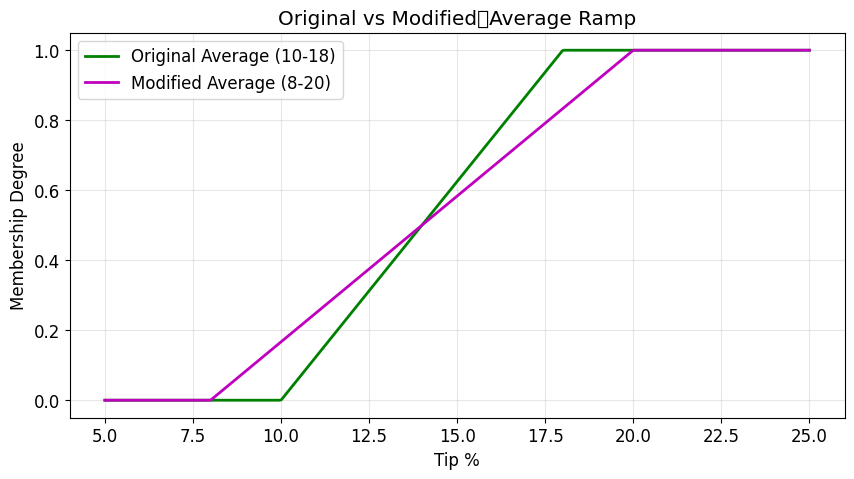

In [15]:
def tip_average_modified(x):
				"""Modified average ramp: mu=0 at 8%, mu=1 at 20%."""
				return ramp_ascending(x, 8, 20)

# Plot original vs modified average ramp
x_tip = np.linspace(5, 25, 500)
plt.figure(figsize=(10, 5))
plt.plot(x_tip, tip_average(x_tip), 'g-', lw=2, label='Original Average (10-18)')
plt.plot(x_tip, tip_average_modified(x_tip), 'm-', lw=2, label='Modified Average (8-20)')
plt.title('Original vs Modified	Average Ramp')
plt.xlabel('Tip %')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
**Why not triangles?** Try replacing the `inv_cheap` function to invert a triangle (e.g. Triangle(0, 5, 10)). For a firing strength of 0.6, how many solutions does the equation $\mu(z) = 0.6$ have? What does this mean for Tsukamoto inference?

In [16]:
# Exercise: Implement a Tsukamoto engine with the modified average ramp and compare outputs.
def tsukamoto_tipper_modified(service_val, food_val):
				"""Compute tip using Tsukamoto inference with modified average ramp."""
				# Fuzzify
				mu_p = service_poor(service_val)
				mu_g = service_good(service_val)
				mu_e = service_excellent(service_val)
				mu_r = food_rancid(food_val)
				mu_d = food_delicious(food_val)

				# Rule firing strengths
				w1 = max(mu_p, mu_r)         # poor OR rancid -> cheap
				w2 = mu_g                    # good -> average
				w3 = max(mu_e, mu_d)         # excellent OR delicious -> generous

				# Invert monotonic output MFs (modified average)
				z1 = inv_cheap(w1)
				z2 = 8 + 12 * np.clip(w2, 0, 1)  # modified average: z = 8 + 12*w
				z3 = inv_generous(w3)

				# Weighted average
				denom = w1 + w2 + w3
				if denom == 0:
								return 15.0  # default: middle of range
				return (w1 * z1 + w2 * z2 + w3 * z3) / denom

print(f"Modified Tsukamoto tip for service={service}, food={food}: {tsukamoto_tipper_modified(service, food):.2f}%")

Modified Tsukamoto tip for service=7, food=3: 14.42%


---

Explain why a step function centred at a constant $c$ always inverts to $z = c$ regardless of firing strength.

__Answer:__ A step function centred at a constant $c$ has a membership degree of 1 for all $z \geq c$ and 0 for all $z < c$. When we invert this MF, we are solving for $z$ such that $\mu(z) = w$.	
Since the step function jumps from 0 to 1 at $z = c$, any firing strength

---

## Summary

In this notebook you have:

- Learned that Tsukamoto inference requires **monotonic output membership functions** (ramps or sigmoids), which makes each rule's output uniquely invertible
- Implemented the full Tsukamoto inference pipeline **from scratch**: fuzzification → rule evaluation → MF inversion → weighted average
- Verified your implementation against **pyfuzzylite**
- Compared **Mamdani, Sugeno, and Tsukamoto** on the same tipper problem, observing how the choice of output representation affects the final result

The key trade-off: Tsukamoto gains computational efficiency (like Sugeno) while retaining fuzzy output MFs (like Mamdani), but the monotonic constraint limits how output knowledge can be represented. In practice, Tsukamoto is the least commonly used of the three models — Mamdani is preferred when interpretability matters, and Sugeno is preferred when efficiency matters.